In [3]:
from loadmodules import *
import specKit
import fitting
import figureMarkup
import phomKit

Original number of targets: 284
iteration 1: 273 stars left.
Best-calibration relationship is SHK = 5.132+/-0.276 * SIndex + -0.865+/-0.066
Median formal error of SIndex: 0.033
Standard deviation of the residuals: 0.084
Median formal error of SIndex for faint and bright stars: 0.045
Standard deviation of the residuals for faint and bright stars: 0.095
Number of stars in the final sample:  273


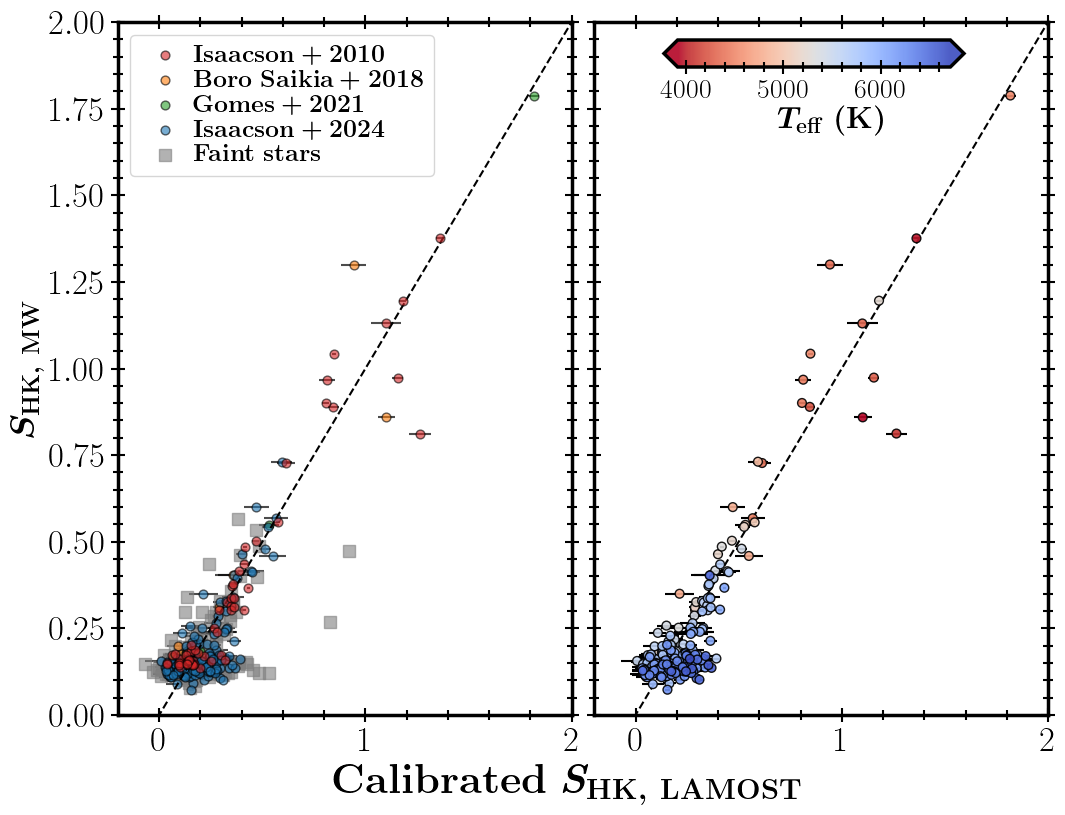

In [ ]:
SIndexResults = pd.read_csv("../Data/SIndexCalibrationBrightStars.csv")
fainStars = pd.read_csv("../Data/SIndexCalibrationFaintStars.csv")

# 
nTargets = len(SIndexResults)
nTargetsOri = nTargets
nIteration = 0
print(f"Original number of targets: {nTargetsOri}")

while True:
    x = SIndexResults.SHK.values
    y = SIndexResults.SIndex.values
    stat_bin = kepler.bin(x=x, y=y, bins=np.linspace(0.1, 0.6, 12), suffixes=["L", "M"], LdivideN=False)
    stat_bin = stat_bin.apply(pd.to_numeric)
    stat_bin.dropna(subset=["median_L", "median_M"], inplace=True)
    slope, slopeE, interc, intercE, _, _ = fitting.linear_fit(stat_bin.median_M.values, stat_bin.median_L.values) 
    SIndexResults = SIndexResults[SIndexResults.SIndex * slope + interc > 0].reset_index(drop=True)
    

    if len(SIndexResults) == nTargets: break
    nIteration += 1
    print(f"iteration {nIteration}: {len(SIndexResults)} stars left.")
    nTargets = len(SIndexResults)
print(f"Best-calibration relationship is SHK = {slope:.3f}+/-{slopeE:.3f} * SIndex + {interc:.3f}+/-{intercE:.3f}")

# calibrate S index.
SIndexResults.loc[:, "SIndexCalibrated"] = slope * SIndexResults.loc[:, "SIndex"] + interc
SIndexResults.loc[:, "SIndexSigmaCalibrated"] =  slope * SIndexResults.loc[:, "SIndexSigma"]
fainStars.loc[:, "SIndexCalibrated"] = slope * fainStars.loc[:, "SIndex"] + interc
fainStars.loc[:, "SIndexSigmaCalibrated"] =  slope * fainStars.loc[:, "SIndexSigma"]

# print median formal errors for bright stars.
print(f"Median formal error of SIndex: {np.median(SIndexResults.SIndexSigmaCalibrated):.3f}")
# print std of the residuals for bright stars.
residuals = SIndexResults.SHK - SIndexResults.SIndexCalibrated
print(f"Standard deviation of the residuals: {np.std(residuals):.3f}")
# print median formal error for faint and bright stars.
starsbrightfaint = pd.concat([SIndexResults, fainStars], axis=0, ignore_index=True)
print(f"Median formal error of SIndex for faint and bright stars: {np.median(starsbrightfaint.SIndexSigmaCalibrated):.3f}")
# print std of the residuals for faint and bright stars.
residuals = starsbrightfaint.SHK - starsbrightfaint.SIndexCalibrated
print(f"Standard deviation of the residuals for faint and bright stars: {np.std(residuals):.3f}")



fig, ax = plt.subplots(1, 2, figsize=(12, 9), sharex=True, sharey=True)
# left panel.
ax[0].errorbar(SIndexResults["SIndexCalibrated"], SIndexResults["SHK"], xerr=SIndexResults["SIndexSigmaCalibrated"], fmt="none", c="k", alpha=0.7, zorder=1)
cond = SIndexResults.source == "Isaacson2010"
ax[0].scatter(SIndexResults[cond]["SIndexCalibrated"], SIndexResults[cond]["SHK"], s=40, fc="tab:red", alpha=0.6, zorder=4, ec="k", lw=1., label=r"$\boldsymbol{\rm{Isaacson+2010}}$")
cond = SIndexResults.source == "BoroSaikia2018"
ax[0].scatter(SIndexResults[cond]["SIndexCalibrated"], SIndexResults[cond]["SHK"], s=40, fc="tab:orange", alpha=0.6, zorder=2, ec="k", lw=1., label=r"$\boldsymbol{\rm{Boro~Saikia+2018}}$")
cond = SIndexResults.source == "GomesDaSilva2021"
ax[0].scatter(SIndexResults[cond]["SIndexCalibrated"], SIndexResults[cond]["SHK"], s=40, fc="tab:green", alpha=0.6, zorder=2, ec="k", lw=1., label=r"$\boldsymbol{\rm{Gomes+2021}}$")
cond = SIndexResults.source == "Isaacson2024"
ax[0].scatter(SIndexResults[cond]["SIndexCalibrated"], SIndexResults[cond]["SHK"], s=40, fc="tab:blue", alpha=0.6, zorder=2, ec="k", lw=1., label=r"$\boldsymbol{\rm{Isaacson+2024}}$")
ax[0].scatter(fainStars["SIndexCalibrated"], fainStars["SHK"], s=70, fc="tab:gray", alpha=0.6, zorder=1, marker="s", label=r"$\boldsymbol{\rm{Faint~stars}}$")

ax[0].plot([-0.2, 2.6], [-0.2, 2.6], c="k", ls="--")
ax[0].set_ylabel(r"$\boldsymbol{S_{\rm HK,~MW}}$")
fig.supxlabel(r"$\boldsymbol{\rm{Calibrated}~ \it{S_{\rm HK,~LAMOST}}}$",)
ax[0].set_xlim(-0.2, 2)
ax[0].set_ylim(0, 2.0)
ax[0].legend(fontsize=18, labelspacing=0.1, handletextpad=0.1, loc="upper left")
# right panel.
ax[1].errorbar(SIndexResults["SIndexCalibrated"], SIndexResults["SHK"], xerr=SIndexResults["SIndexSigmaCalibrated"], fmt="none", c="k", zorder=2)
cb1 = ax[1].scatter(SIndexResults["SIndexCalibrated"], SIndexResults["SHK"], s=40, c=SIndexResults.teff, alpha=0.9, zorder=4, ec="k", lw=1, cmap="coolwarm_r")
cax = fig.add_axes([0.58, 0.83, 0.25, 0.03])
cbar = plt.colorbar(cb1, cax=cax, orientation="horizontal", extend='both')
cbar.ax.tick_params(which='major', labelsize=20)   
fig.text(0.72, 0.77, r"$\boldsymbol{T_{\rm{eff}}~\rm{(K)}}$", ha='center', va='center', fontsize=22)
ax[1].plot([-0.2, 2.6], [-0.2, 2.6], c="k", ls="--")
plt.subplots_adjust(wspace=0.05)
print("Number of stars in the final sample: ", len(SIndexResults))
plt.savefig("../Figures/SIndexCalibrationMeanIndexes.jpg", dpi=400, bbox_inches="tight")
plt.savefig("../Figures/SIndexCalibrationMeanIndexes.pdf", dpi=400, bbox_inches="tight")
